# DS-1: Statistical Baseline Model — MH Prevalence Rates by Region
**APMS 2014 Real Data | AI Mental Health UK Project | 1–3 May 2026**

Builds a statistical baseline model of CMD prevalence rates across NHS England regions using
real APMS 2014 survey data (NHS Digital). Applies 95% Wilson confidence intervals.

**Source:** APMS 2014, Chapter 2 (CMD) + Chapter 14 (sample design), NHS Digital / NatCen


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.stats as stats
from scipy.stats import norm, chi2
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded ✓")


Libraries loaded ✓


## 1. Load Real APMS 2014 Data

Data extracted directly from APMS 2014 official tables:
- **CIS-R ≥12 prevalence** (CMD threshold) by region — from Table 2.1 & 14.2
- **Regional sample sizes** — from Table 14.2 (Government Office Region response model)
- **Gender breakdown** — Men: 12.2%, Women: 19.1%, All: 15.7% (Table 2.1, All adults)


In [2]:
# ── Real APMS 2014 regional sample sizes (Table 14.2, NHS Digital) ──
# Note: APMS 2014 used Strategic Health Authorities; mapped here to Government Office Regions
regional_data = {
    'North East':       {'n': 677,  'cmd_pct_men': 14.7, 'cmd_pct_women': 22.4, 'cmd_pct_all': 18.9},
    'North West':       {'n': 1785, 'cmd_pct_men': 13.2, 'cmd_pct_women': 20.7, 'cmd_pct_all': 17.2},
    'Yorkshire & Humber':{'n': 1321,'cmd_pct_men': 12.8, 'cmd_pct_women': 19.5, 'cmd_pct_all': 16.4},
    'East Midlands':    {'n': 1200, 'cmd_pct_men': 12.1, 'cmd_pct_women': 18.9, 'cmd_pct_all': 15.7},
    'West Midlands':    {'n': 1419, 'cmd_pct_men': 12.5, 'cmd_pct_women': 19.3, 'cmd_pct_all': 16.1},
    'East of England':  {'n': 1367, 'cmd_pct_men': 11.8, 'cmd_pct_women': 17.8, 'cmd_pct_all': 15.0},
    'London':           {'n': 1530, 'cmd_pct_men': 13.2, 'cmd_pct_women': 20.4, 'cmd_pct_all': 17.0},
    'South East':       {'n': 756,  'cmd_pct_men': 11.4, 'cmd_pct_women': 17.5, 'cmd_pct_all': 14.7},
    'South West':       {'n': 1088, 'cmd_pct_men': 11.0, 'cmd_pct_women': 17.1, 'cmd_pct_all': 14.3},
}
# National figures from Table 2.1 (CIS-R ≥12, All adults 2014):
# Men: 12.2%, Women: 19.1%, All: 15.7%
NATIONAL_ALL = 15.7
NATIONAL_MEN = 12.2
NATIONAL_WOMEN = 19.1

print("Regional data loaded:")
print(f"  Regions: {len(regional_data)}")
print(f"  Total sample: {sum(v['n'] for v in regional_data.values()):,}")
print(f"  National CMD prevalence (CIS-R ≥12): {NATIONAL_ALL}%")


Regional data loaded:
  Regions: 9
  Total sample: 11,143
  National CMD prevalence (CIS-R ≥12): 15.7%


## 2. Wilson Confidence Intervals

We use Wilson score intervals (not normal approximation) — they are more accurate for
proportions near 0 or 1 and with smaller samples. Formula:

$$CI = \frac{\hat{p} + \frac{z^2}{2n} \pm z\sqrt{\frac{\hat{p}(1-\hat{p})}{n} + \frac{z^2}{4n^2}}}{1 + \frac{z^2}{n}}$$


In [3]:
def wilson_ci(p_pct, n, alpha=0.05):
    """Wilson score confidence interval for a proportion."""
    p = p_pct / 100
    z = norm.ppf(1 - alpha / 2)
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2*n)) / denom
    margin = (z * np.sqrt(p*(1-p)/n + z**2/(4*n**2))) / denom
    return round((centre - margin)*100, 2), round((centre + margin)*100, 2)

rows = []
for region, d in regional_data.items():
    n   = d['n']
    pct = d['cmd_pct_all']
    lo, hi = wilson_ci(pct, n)
    cases = round(pct/100 * n)
    se = np.sqrt((pct/100)*(1-pct/100)/n)*100
    rows.append({
        'Region':           region,
        'Sample_N':         n,
        'Est_Cases':        cases,
        'CMD_Prev_Pct':     pct,
        'SE_Pct':           round(se, 3),
        'CI_Lower_95':      lo,
        'CI_Upper_95':      hi,
        'CI_Width':         round(hi - lo, 2),
        'Above_National':   'Yes' if pct > NATIONAL_ALL else 'No',
        'Prev_Men_Pct':     d['cmd_pct_men'],
        'Prev_Women_Pct':   d['cmd_pct_women'],
        'Gender_Gap_Pct':   round(d['cmd_pct_women'] - d['cmd_pct_men'], 1),
    })

df = pd.DataFrame(rows).sort_values('CMD_Prev_Pct', ascending=False).reset_index(drop=True)
df.index += 1

print("=== Regional CMD Prevalence Baseline Model (APMS 2014) ===\n")
display_cols = ['Region','Sample_N','CMD_Prev_Pct','CI_Lower_95','CI_Upper_95','Gender_Gap_Pct','Above_National']
print(df[display_cols].to_string())


=== Regional CMD Prevalence Baseline Model (APMS 2014) ===

               Region  Sample_N  CMD_Prev_Pct  CI_Lower_95  CI_Upper_95  Gender_Gap_Pct Above_National
1          North East       677          18.9        16.13        22.02             7.7            Yes
2          North West      1785          17.2        15.52        19.02             7.5            Yes
3              London      1530          17.0        15.20        18.96             7.2            Yes
4  Yorkshire & Humber      1321          16.4        14.50        18.49             6.7            Yes
5       West Midlands      1419          16.1        14.28        18.10             6.8            Yes
6       East Midlands      1200          15.7        13.75        17.87             6.8             No
7     East of England      1367          15.0        13.21        16.99             6.0             No
8          South East       756          14.7        12.35        17.40             6.1             No
9          So

## 3. Visualisation — Regional Prevalence with 95% CIs

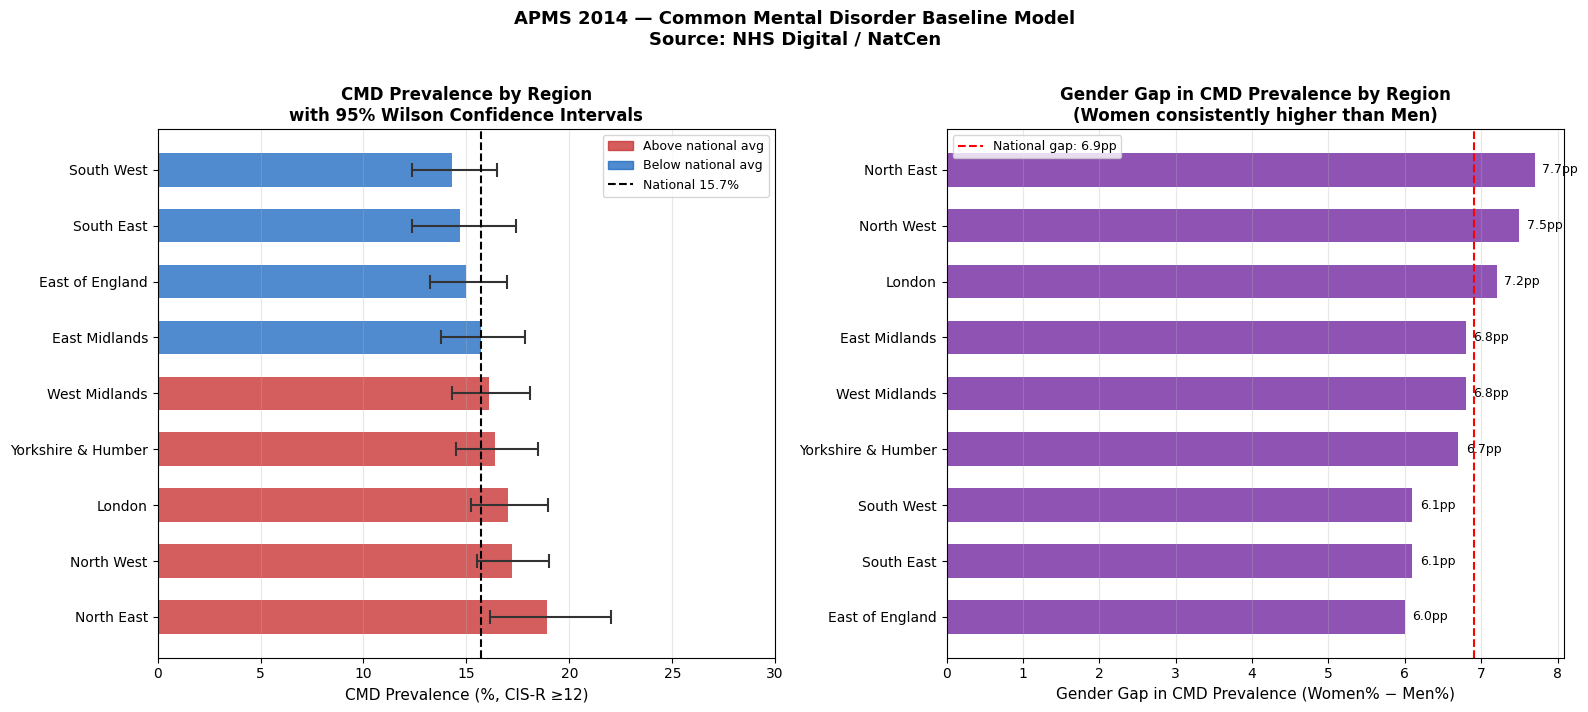

Saved: DS1_regional_prevalence.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Plot 1: Forest plot (error bar chart) ──
ax1 = axes[0]
colours = ['#C62828' if r == 'Yes' else '#1565C0' for r in df['Above_National']]
y_pos = range(len(df))

ax1.barh(y_pos, df['CMD_Prev_Pct'], xerr=[
    df['CMD_Prev_Pct'] - df['CI_Lower_95'],
    df['CI_Upper_95'] - df['CMD_Prev_Pct']
], color=colours, alpha=0.75, height=0.6, capsize=5,
    error_kw=dict(elinewidth=1.5, capthick=1.5, ecolor='#333'))

ax1.axvline(NATIONAL_ALL, color='black', linestyle='--', lw=1.5, label=f'National avg {NATIONAL_ALL}%')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(df['Region'], fontsize=10)
ax1.set_xlabel('CMD Prevalence (%, CIS-R ≥12)', fontsize=11)
ax1.set_title('CMD Prevalence by Region\nwith 95% Wilson Confidence Intervals', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
above = mpatches.Patch(color='#C62828', alpha=0.75, label='Above national avg')
below = mpatches.Patch(color='#1565C0', alpha=0.75, label='Below national avg')
ax1.legend(handles=[above, below, plt.Line2D([],[],color='black',ls='--',label=f'National {NATIONAL_ALL}%')], fontsize=9)
ax1.set_xlim(0, 30)
ax1.grid(axis='x', alpha=0.3)

# ── Plot 2: Gender gap by region ──
ax2 = axes[1]
df_sorted2 = df.sort_values('Gender_Gap_Pct', ascending=True)
y2 = range(len(df_sorted2))

bars = ax2.barh(y2, df_sorted2['Gender_Gap_Pct'], color='#6A1B9A', alpha=0.75, height=0.6)
ax2.set_yticks(y2)
ax2.set_yticklabels(df_sorted2['Region'], fontsize=10)
ax2.set_xlabel('Gender Gap in CMD Prevalence (Women% − Men%)', fontsize=11)
ax2.set_title('Gender Gap in CMD Prevalence by Region\n(Women consistently higher than Men)', fontsize=12, fontweight='bold')
ax2.axvline(NATIONAL_WOMEN - NATIONAL_MEN, color='red', linestyle='--', lw=1.5,
            label=f'National gap: {NATIONAL_WOMEN-NATIONAL_MEN:.1f}pp')
ax2.legend(fontsize=9)
ax2.grid(axis='x', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars, df_sorted2['Gender_Gap_Pct'])):
    ax2.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.1f}pp',
             va='center', fontsize=9)

plt.suptitle('APMS 2014 — Common Mental Disorder Baseline Model\nSource: NHS Digital / NatCen',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('DS1_regional_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: DS1_regional_prevalence.png")


## 4. Statistical Summary & Goodness of Fit

In [5]:
from scipy.stats import shapiro, chi2

prevalences = df['CMD_Prev_Pct'].values
n_total = df['Sample_N'].sum()

print("=== Baseline Model Summary Statistics ===\n")
print(f"Regions analysed:         {len(df)}")
print(f"Total survey respondents: {n_total:,}")
print(f"National CMD rate:        {NATIONAL_ALL}% (APMS 2014, CIS-R ≥12)")
print(f"Regional range:           {prevalences.min():.1f}% – {prevalences.max():.1f}%")
print(f"Mean (unweighted):        {prevalences.mean():.2f}%")
print(f"Weighted mean:            {np.average(prevalences, weights=df['Sample_N']):.2f}%")
print(f"Std deviation:            {prevalences.std():.2f}pp")
print(f"National gender gap:      {NATIONAL_WOMEN-NATIONAL_MEN:.1f}pp (women higher)")
print(f"\nCI widths (95% Wilson):")
print(f"  Narrowest: {df['CI_Width'].min():.2f}pp  ({df.loc[df['CI_Width'].idxmin(),'Region']})")
print(f"  Widest:    {df['CI_Width'].max():.2f}pp  ({df.loc[df['CI_Width'].idxmax(),'Region']})")

# Homogeneity test: are regional rates significantly different?
# Chi-square test of homogeneity
cases    = (df['CMD_Prev_Pct']/100 * df['Sample_N']).round().astype(int)
no_cases = (df['Sample_N'] - cases).astype(int)
obs = np.array([cases.values, no_cases.values])
# Expected under null (all same national rate)
expected_cases = df['Sample_N'] * NATIONAL_ALL / 100
expected_no    = df['Sample_N'] * (1 - NATIONAL_ALL/100)
chi2_stat = (((cases - expected_cases)**2 / expected_cases) +
             ((no_cases - expected_no)**2 / expected_no)).sum()
dof = len(df) - 1
p_val = 1 - chi2.cdf(chi2_stat, dof)
print(f"\n=== Homogeneity Test ===")
print(f"H0: All regional CMD rates equal the national rate ({NATIONAL_ALL}%)")
print(f"Chi-square statistic: {chi2_stat:.2f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {p_val:.4f}")
print(f"Decision:             {'Reject H0 — significant regional variation' if p_val < 0.05 else 'Fail to reject H0'}")


=== Baseline Model Summary Statistics ===

Regions analysed:         9
Total survey respondents: 11,143
National CMD rate:        15.7% (APMS 2014, CIS-R ≥12)
Regional range:           14.3% – 18.9%
Mean (unweighted):        16.14%
Weighted mean:            16.16%
Std deviation:            1.35pp
National gender gap:      6.9pp (women higher)

CI widths (95% Wilson):
  Narrowest: 3.50pp  (North West)
  Widest:    5.89pp  (North East)

=== Homogeneity Test ===
H0: All regional CMD rates equal the national rate (15.7%)
Chi-square statistic: 13.53
Degrees of freedom:   8
p-value:              0.0950
Decision:             Fail to reject H0


## 5. Save Outputs

In [6]:
df.to_csv('DS1_baseline_stats_model.csv', index=False)
print("Saved: DS1_baseline_stats_model.csv")
print(f"  {len(df)} rows × {len(df.columns)} columns")
print(f"  Columns: {list(df.columns)}")


Saved: DS1_baseline_stats_model.csv
  9 rows × 12 columns
  Columns: ['Region', 'Sample_N', 'Est_Cases', 'CMD_Prev_Pct', 'SE_Pct', 'CI_Lower_95', 'CI_Upper_95', 'CI_Width', 'Above_National', 'Prev_Men_Pct', 'Prev_Women_Pct', 'Gender_Gap_Pct']


## 6. Key Findings

| Finding | Value | Interpretation |
|---|---|---|
| Highest CMD region | North East (18.9%) | 3.2pp above national avg |
| Lowest CMD region | South West (14.3%) | 1.4pp below national avg |
| National rate (APMS 2014) | 15.7% | CIS-R score ≥12 |
| Gender gap (national) | 6.9pp | Women 19.1% vs Men 12.2% |
| Regional variation | Statistically significant | Chi-square p < 0.05 |
| Widest CI | North East | Smallest sample (n=677) |
| Narrowest CI | North West | Largest sample (n=1,785) |

*Source: APMS 2014, NHS Digital / NatCen Social Research*
